In [49]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Notebook is in src/, so ../results/figures points to project_root/results/figures
fig_dir = Path("../results/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

base = pd.read_csv("featureDf_baseline.csv")
base.columns

meta = pd.read_csv("../data/new_metadata.csv")

## Create base_color that has only the color features and img_id

In [50]:
color_cols = [
    'hsv_mean_h', 'hsv_mean_s', 'hsv_mean_v',
    'hsv_std_h', 'hsv_std_s', 'hsv_std_v',
    'sp_hsv_std_h', 'sp_hsv_std_s', 'sp_hsv_std_v',
    'rel_hsv_diff_h', 'rel_hsv_diff_s', 'rel_hsv_diff_v'
]

base_color = base[['img_id'] + color_cols].copy()

base_color.head()

,img_id,hsv_mean_h,hsv_mean_s,hsv_mean_v,hsv_std_h,hsv_std_s,hsv_std_v,sp_hsv_std_h,sp_hsv_std_s,sp_hsv_std_v,rel_hsv_diff_h,rel_hsv_diff_s,rel_hsv_diff_v
0,PAT_1516_1765_530.png,0.596812,0.721593,0.562349,0.006291,0.074704,0.049599,0.006266,0.081665,0.049079,0.009937,0.188500,0.083608
1,PAT_46_881_939.png,0.731211,0.200618,0.668742,0.062351,0.131785,0.043039,0.056869,0.124764,0.038754,0.065885,0.048277,0.017007
2,PAT_1545_1867_547.png,0.674872,0.495146,0.606443,0.009140,0.058582,0.069610,0.007575,0.051897,0.067342,0.012132,0.077684,0.092984
3,PAT_1989_4061_934.png,0.646455,0.214990,0.608748,0.027248,0.064702,0.029728,0.026081,0.063807,0.030374,0.034895,0.020770,0.000674
4,PAT_684_1302_588.png,0.669910,0.397585,0.526509,0.015145,0.059756,0.038256,0.015093,0.059827,0.034487,0.027133,0.050405,0.010770


### Drop the rows with NaN values

In [51]:
display(base_color.isna().sum().sort_values(ascending=False))
df = base_color.dropna(subset=color_cols).copy()
display(df.isna().sum().sort_values(ascending=False))
df.shape

sp_hsv_std_s      2
sp_hsv_std_h      2
sp_hsv_std_v      2
hsv_mean_h        0
img_id            0
hsv_std_h         0
hsv_mean_v        0
hsv_mean_s        0
hsv_std_v         0
hsv_std_s         0
rel_hsv_diff_h    0
rel_hsv_diff_s    0
rel_hsv_diff_v    0
dtype: int64

img_id            0
hsv_mean_h        0
hsv_mean_s        0
hsv_mean_v        0
hsv_std_h         0
hsv_std_s         0
hsv_std_v         0
sp_hsv_std_h      0
sp_hsv_std_s      0
sp_hsv_std_v      0
rel_hsv_diff_h    0
rel_hsv_diff_s    0
rel_hsv_diff_v    0
dtype: int64

(1943, 13)

Add diagnosises

In [52]:
# Drop all previous diagnostic columns
#diagnostic_cols = [col for col in df.columns if col.startswith('diagnostic')]
#df = df.drop(columns=diagnostic_cols)


Add binary values for benign = 0 malignant = 1

In [53]:
df = df.merge(
    meta[['img_id', 'diagnostic']],
    on='img_id',
    how='left'
)


cancer_classes = ['BCC', 'MEL', 'SCC']

df['target'] = df['diagnostic'].apply(
    lambda x: 1 if x in cancer_classes else 0
)



## T-tests

In [54]:
from scipy.stats import ttest_ind
import pandas as pd
import numpy as np

color_cols = [
    'hsv_mean_h', 'hsv_mean_s', 'hsv_mean_v',
    'hsv_std_h', 'hsv_std_s', 'hsv_std_v',
    'sp_hsv_std_h', 'sp_hsv_std_s', 'sp_hsv_std_v',
    'rel_hsv_diff_h', 'rel_hsv_diff_s', 'rel_hsv_diff_v'
]

results = []

for col in color_cols:
    benign = df.loc[df['target'] == 0, col].dropna()
    malignant = df.loc[df['target'] == 1, col].dropna()
    
    # Welch's t-test: does not assume equal variance
    t_stat, p_value = ttest_ind(malignant, benign, equal_var=False)
    
    # Mean difference: malignant - benign
    mean_benign = benign.mean()
    mean_malignant = malignant.mean()
    mean_difference = mean_malignant - mean_benign
    
    # Cohen's d effect size
    pooled_std = np.sqrt((benign.std()**2 + malignant.std()**2) / 2)
    cohen_d = mean_difference / pooled_std if pooled_std != 0 else np.nan
    
    results.append({
        'feature': col,
        'benign_mean': mean_benign,
        'malignant_mean': mean_malignant,
        'mean_difference': mean_difference,
        't_statistic': t_stat,
        'p_value': p_value,
        'cohen_d': cohen_d
    })

ttest_results = pd.DataFrame(results)

# Optional: Bonferroni correction because we test 12 features
ttest_results['p_value_bonferroni'] = ttest_results['p_value'] * len(color_cols)
ttest_results['p_value_bonferroni'] = ttest_results['p_value_bonferroni'].clip(upper=1)

# Sort by strongest effect size
ttest_results = ttest_results.sort_values(
    by='cohen_d',
    key=lambda x: abs(x),
    ascending=False
)

ttest_results

,feature,benign_mean,malignant_mean,mean_difference,t_statistic,p_value,cohen_d,p_value_bonferroni
4,hsv_std_s,0.078254,0.100794,0.022541,14.214802,1.116580e-43,0.642655,1.339896e-42
7,sp_hsv_std_s,0.070353,0.089657,0.019304,13.145123,7.253960e-38,0.594803,8.704751e-37
0,hsv_mean_h,0.630557,0.657986,0.027429,7.942528,3.373090e-15,0.361441,4.047708e-14
11,rel_hsv_diff_v,0.067057,0.049883,-0.017174,-6.163472,8.879333e-10,-0.281976,1.065520e-08
1,hsv_mean_s,0.337139,0.372047,0.034908,5.349697,9.866644e-08,0.243146,1.183997e-06
2,hsv_mean_v,0.602012,0.625761,0.023749,3.893768,1.021576e-04,0.177277,1.225891e-03
5,hsv_std_v,0.076072,0.080973,0.004901,3.128916,1.780656e-03,0.141964,2.136787e-02
3,hsv_std_h,0.041465,0.047258,0.005793,2.074203,3.819313e-02,0.094208,4.583175e-01
6,sp_hsv_std_h,0.035456,0.039617,0.004160,1.595463,1.107727e-01,0.072458,1.000000e+00
8,sp_hsv_std_v,0.068845,0.071245,0.002400,1.534533,1.250629e-01,0.069700,1.000000e+00


## Interpretation of the results

p-value < 0.05 : means the benign and malignant distributions are statistically different for that feature

p_value_bonferroni < 0.05 : is stricter and better because you test many features

cohen_d tells how large the difference is - bigger absolute values mean stronger separation

mean_difference > 0 : means malignant lesions have a higher average value for that feature

mean_difference < 0 : means benign lesions have a higher average value

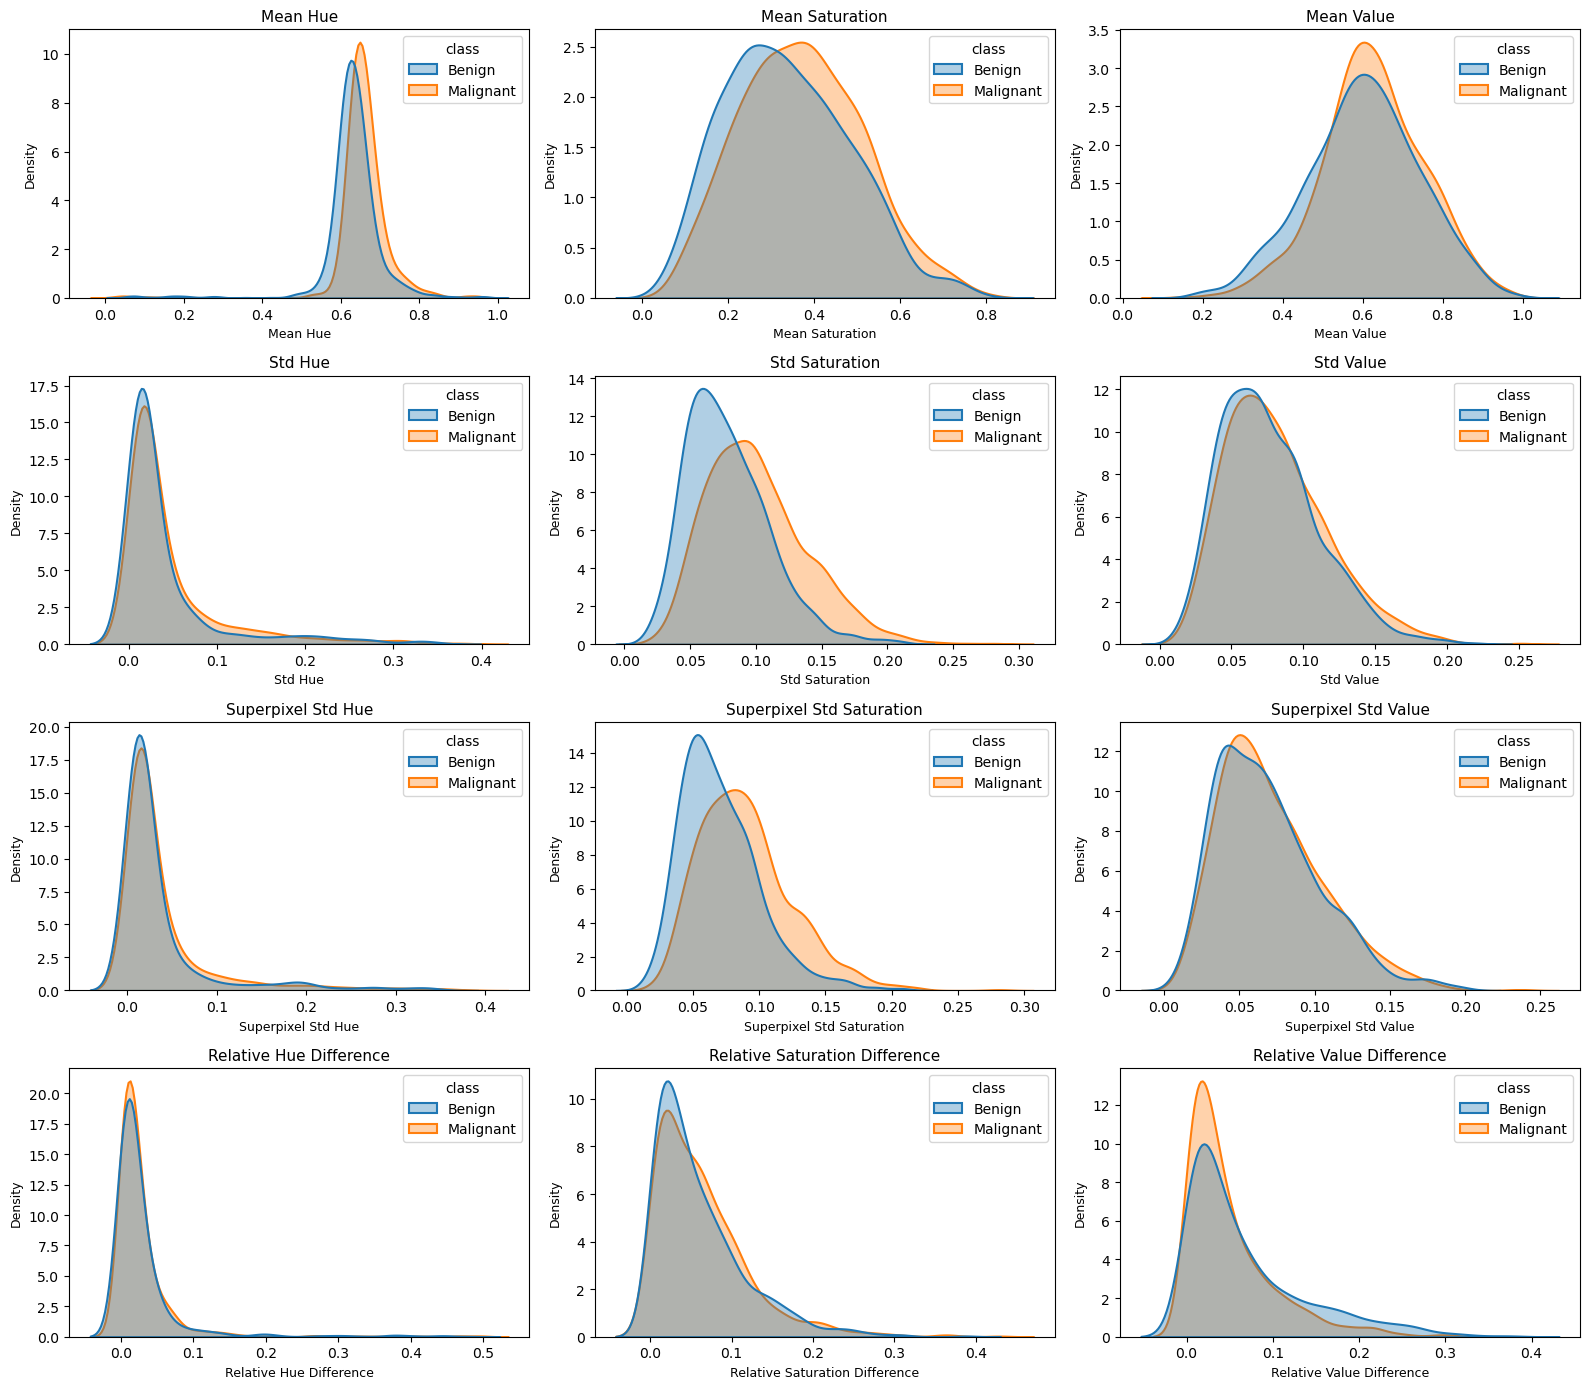

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

color_cols = [
    'hsv_mean_h', 'hsv_mean_s', 'hsv_mean_v',
    'hsv_std_h', 'hsv_std_s', 'hsv_std_v',
    'sp_hsv_std_h', 'sp_hsv_std_s', 'sp_hsv_std_v',
    'rel_hsv_diff_h', 'rel_hsv_diff_s', 'rel_hsv_diff_v'
]

# Create readable class names
df_plot = df.copy()
df_plot['class'] = df_plot['target'].map({
    0: 'Benign',
    1: 'Malignant'
})

# Optional: remove rows with missing/infinite values
df_plot = df_plot.replace([np.inf, -np.inf], np.nan)
df_plot = df_plot.dropna(subset=color_cols + ['class'])

# Nice feature names for plot titles
feature_names = {
    'hsv_mean_h': 'Mean Hue',
    'hsv_mean_s': 'Mean Saturation',
    'hsv_mean_v': 'Mean Value',
    'hsv_std_h': 'Std Hue',
    'hsv_std_s': 'Std Saturation',
    'hsv_std_v': 'Std Value',
    'sp_hsv_std_h': 'Superpixel Std Hue',
    'sp_hsv_std_s': 'Superpixel Std Saturation',
    'sp_hsv_std_v': 'Superpixel Std Value',
    'rel_hsv_diff_h': 'Relative Hue Difference',
    'rel_hsv_diff_s': 'Relative Saturation Difference',
    'rel_hsv_diff_v': 'Relative Value Difference'
}

plt.figure(figsize=(16, 14))

for i, col in enumerate(color_cols, 1):
    plt.subplot(4, 3, i)
    
    sns.kdeplot(
        data=df_plot,
        x=col,
        hue='class',
        fill=True,
        common_norm=False,
        alpha=0.35,
        linewidth=1.5
    )
    
    plt.title(feature_names[col], fontsize=11)
    plt.xlabel(feature_names[col], fontsize=9)
    plt.ylabel("Density", fontsize=9)

plt.tight_layout()
plt.savefig(fig_dir / "color_density_plots.png", dpi=300, bbox_inches="tight")
plt.show()

## Correlation matrix

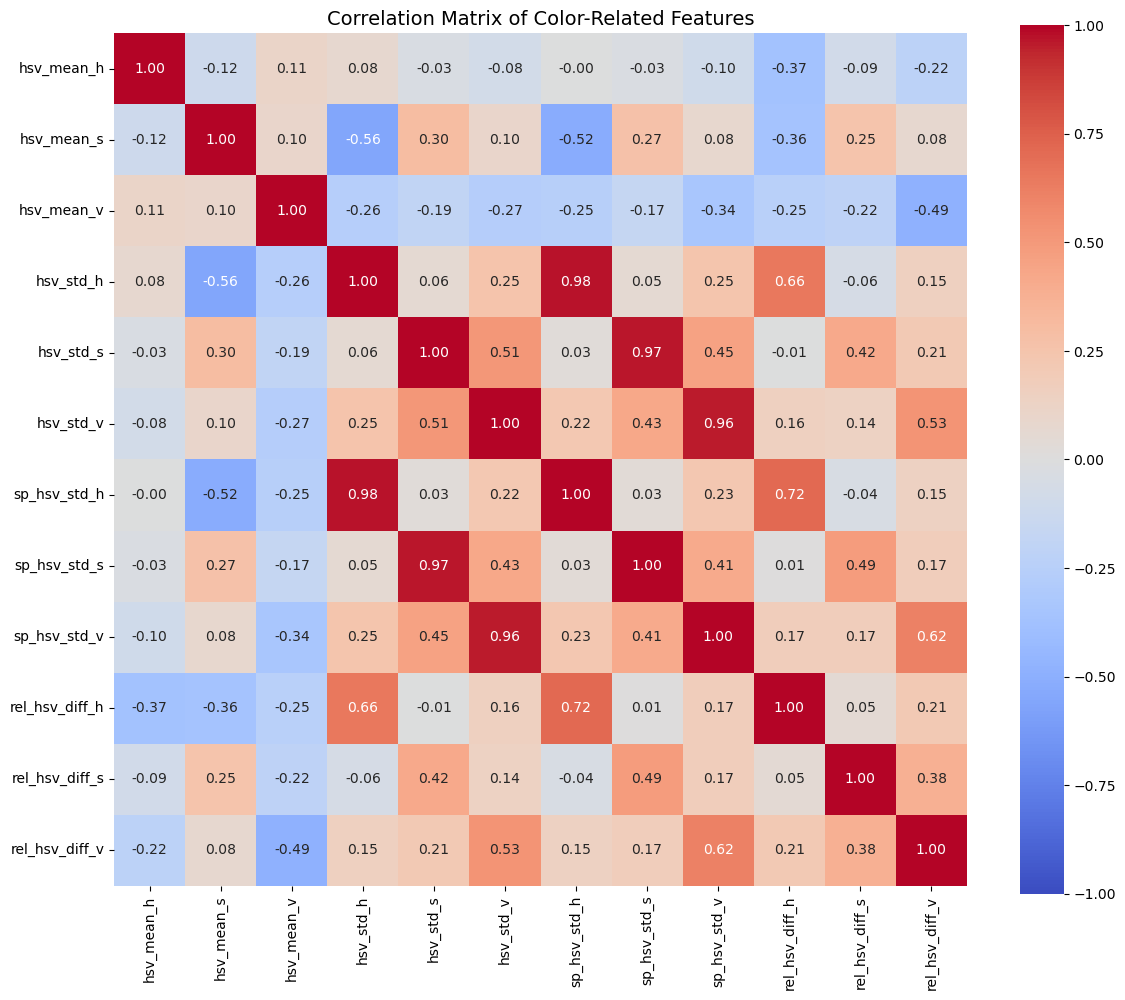

In [56]:
plt.figure(figsize=(12, 10))

corr = df_plot[color_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Correlation Matrix of Color-Related Features", fontsize=14)
plt.tight_layout()
plt.savefig(fig_dir / "color_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()